# Анализ влияния сроков доставки на клиентский опыт (Olist)

**Контекст:** бразильский маркетплейс Olist, ~100 тыс. заказов за 2016–2018 гг

**Задача:** выяснить, как соблюдение сроков доставки влияет на оценки клиентов, и определить регионы, где проблема стоит наиболее остро

## Импортируем библиотеки, подключаемся к PostgreSQL, загружаем CSV и загружаем всё в PostgreSQL:

In [13]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd

In [45]:
engine = create_engine(
    "postgresql+psycopg2://kamy:@localhost:5432/marketplace_db"
)

In [169]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

In [170]:
orders.to_sql("orders", engine, if_exists="replace", index=False)
customers.to_sql("customers", engine, if_exists="replace", index=False)
payments.to_sql("payments", engine, if_exists="replace", index=False)
reviews.to_sql("reviews", engine, if_exists="replace", index=False)

224

## Смотрим структуру таблиц и проверяем данные

In [30]:
display(orders.info())
display(orders.describe())
display(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Колонки с датами хранятся как object, приводим к datetime

In [99]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)
orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [29]:
display(customers.info())
display(customers.describe())
display(customers.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [35]:
display(reviews.info())
display(reviews.describe())
display(reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


None

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [160]:
print("Orders:")
print(f"  Дубликаты order_id: {'есть' if orders['order_id'].duplicated().any() else 'нет'}")
print(f"  Пропуски в дате доставки: {orders['order_delivered_customer_date'].isna().sum()}")
print(f"  Пропуски в обещанной дате: {orders['order_estimated_delivery_date'].isna().sum()}")

print(f"\nCustomers:")
print(f"  Пропуски в штатах: {customers['customer_state'].isna().sum()}")

print(f"\nReviews:")
print(f"  Диапазон оценок: {reviews['review_score'].min()} - {reviews['review_score'].max()}")

Orders:
  Дубликаты order_id: нет
  Пропуски в дате доставки: 2965
  Пропуски в обещанной дате: 0

Customers:
  Пропуски в штатах: 0

Reviews:
  Диапазон оценок: 1 - 5


In [173]:
query = """
SELECT
    ROUND(SUM(payment_value)::numeric, 2) AS общая_выручка,
    ROUND(AVG(payment_value)::numeric, 2) AS средний_чек
FROM payments
"""

metrics_df = pd.read_sql(query, engine)
display(metrics_df)


,общая_выручка,средний_чек
0,16008872.12,154.1


## Анализ: влияние сроков доставки на клиентский опыт

- Для анализа понадобятся четыре таблицы: `orders` (статусы и даты доставки), `customers` (штаты клиентов), `reviews` (оценки) и `payments` (выручка)
- Перед началом проверили ключевые моменты:
- Дубликатов в заказах нет — каждый order_id уникален
- Даты доставки отсутствуют у 3% заказов — это отменённые или незавершённые, они автоматически исключаются из расчётов
- Штаты у всех клиентов заполнены
- Оценки в диапазоне 1–5
- Даты привели к datetime. Данные чистые, можно начинать.

### Считаем, какая доля доставленных заказов пришла позже обещанной даты.

In [145]:
query = """
SELECT
    CASE
        WHEN order_delivered_customer_date::date <= order_estimated_delivery_date::date THEN 'вовремя'
        ELSE 'опоздание'
    END AS статус_доставки,
    COUNT(*) AS количество,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) AS доля
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
GROUP BY статус_доставки
"""
 
delivery_status = pd.read_sql(query, engine)
display(delivery_status)

,статус_доставки,количество,доля
0,опоздание,6534,6.8
1,вовремя,89936,93.2


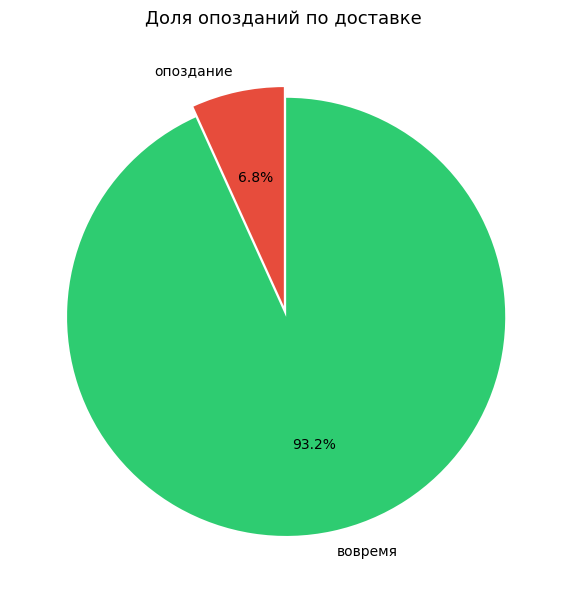

In [161]:
plt.figure(figsize=(6, 6))
colors = ['#E74C3C', '#2ECC71']
plt.pie(delivery_status['количество'], labels=delivery_status['статус_доставки'],
        autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
plt.title('Доля опозданий по доставке', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** 6.8% заказов приходят позже обещанного — **каждый пятнадцатый заказ** не укладывается в срок. За этими цифрами стоят **6 500 реальных клиентов**, которые ждали заказ к определённой дате и не получили его вовремя

### Как опоздания влияют на оценку

Сравниваем среднюю оценку заказов, доставленных вовремя и с опозданием. Гипотеза: клиенты, чей заказ опоздал, ставят более низкие оценки.

In [147]:
query = """
SELECT
    CASE
        WHEN o.order_delivered_customer_date::date <= o.order_estimated_delivery_date::date THEN 'вовремя'
        ELSE 'опоздание'
    END AS статус_доставки,
    ROUND(AVG(r.review_score)::numeric, 2) AS средняя_оценка,
    COUNT(DISTINCT r.review_id) AS всего_отзывов
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY статус_доставки
"""

delivery_rating = pd.read_sql(query, engine)
display(delivery_rating)

,статус_доставки,средняя_оценка,всего_отзывов
0,вовремя,4.29,89303
1,опоздание,2.27,6389


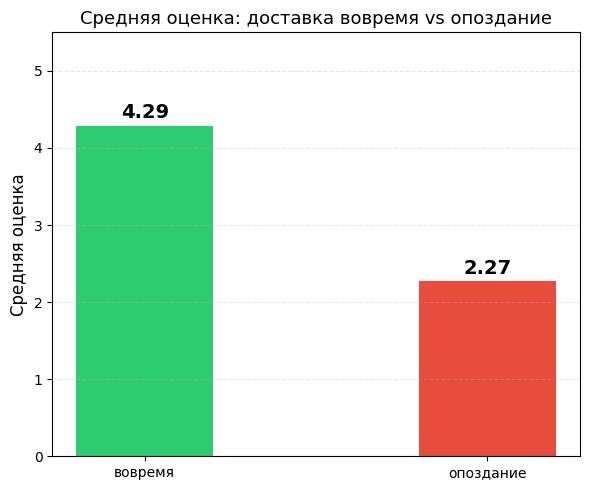

In [148]:
plt.figure(figsize=(6, 5))

plt.bar(delivery_rating['статус_доставки'], delivery_rating['средняя_оценка'],
        color=['#2ECC71', '#E74C3C'], width=0.4)

for i, (status, rating) in enumerate(zip(delivery_rating['статус_доставки'], delivery_rating['средняя_оценка'])):
    plt.text(i, rating + 0.1, str(rating), ha='center', fontsize=14, fontweight='bold')

plt.title('Средняя оценка: доставка вовремя vs опоздание', fontsize=13)
plt.ylabel('Средняя оценка', fontsize=12)
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** средняя оценка при доставке в срок — **4.3**, при опоздании — **2.3**. Нарушение сроков прямо связано с падением оценки.

### Где проблема сильнее всего

Раскладываем опоздания по штатам и накладываем на карту выручки, чтобы понять, где потери наиболее чувствительны.

In [152]:
query = """
SELECT
    c.customer_state AS штат,
    COUNT(*) AS всего_заказов,
    ROUND(100.0 * SUM(CASE WHEN o.order_delivered_customer_date::date > o.order_estimated_delivery_date::date THEN 1 ELSE 0 END) / COUNT(*), 1) AS доля_опозданий
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY c.customer_state
HAVING COUNT(*) >= 100
ORDER BY доля_опозданий DESC
"""

state_delays = pd.read_sql(query, engine)
display(state_delays)

,штат,всего_заказов,доля_опозданий
0,AL,397,21.4
1,MA,717,17.4
2,SE,335,15.2
3,PI,476,13.9
4,CE,1279,13.8
5,BA,3256,12.2
6,RJ,12350,12.1
7,PA,946,11.2
8,ES,1995,10.7
9,PB,517,10.4


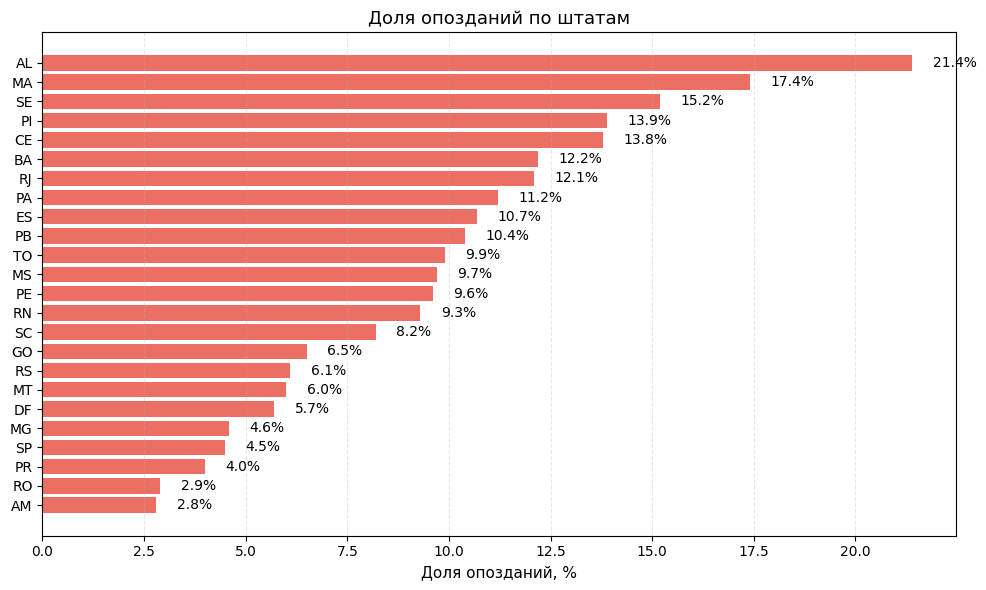

In [154]:
plt.figure(figsize=(10, 6))

data = state_delays.sort_values('доля_опозданий', ascending=True)

plt.barh(data['штат'], data['доля_опозданий'], color='#E74C3C', alpha=0.8)

plt.title('Доля опозданий по штатам', fontsize=13)
plt.xlabel('Доля опозданий, %', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, (state, pct) in enumerate(zip(data['штат'], data['доля_опозданий'])):
    plt.text(pct + 0.5, i, f'{pct}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [171]:
query = """
SELECT
    c.customer_state AS штат,
    COUNT(DISTINCT o.order_id) AS заказов,
    ROUND(SUM(p.payment_value)::numeric, 2) AS выручка
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY выручка DESC
"""

state_revenue = pd.read_sql(query, engine)


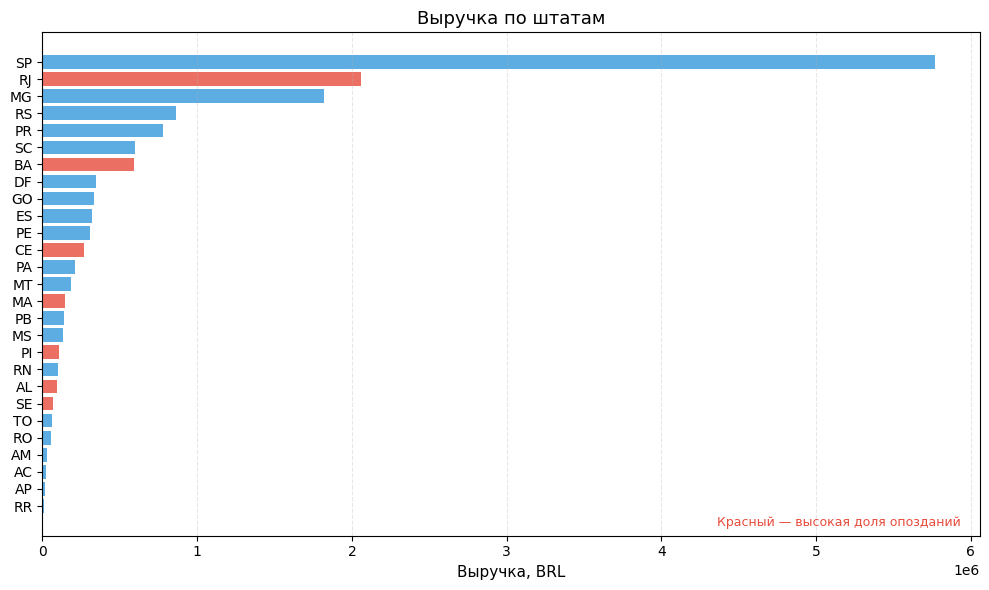

In [172]:
plt.figure(figsize=(10, 6))

data = state_revenue.sort_values('выручка', ascending=True)

problem_states = ['AL', 'MA', 'SE', 'PI', 'CE', 'RJ', 'BA']
colors = ['#E74C3C' if s in problem_states else '#3498DB' for s in data['штат']]

plt.barh(data['штат'], data['выручка'], color=colors, alpha=0.8)

plt.title('Выручка по штатам', fontsize=13)
plt.xlabel('Выручка, BRL', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.text(0.98, 0.02, 'Красный — высокая доля опозданий', transform=plt.gca().transAxes, ha='right', fontsize=9, color='#E74C3C')

plt.tight_layout()
plt.show()

### Итоговый вывод

Каждый шестой заказ (6.8%) доставляется с опозданием, что сказывается на лояльности покупателей: средняя оценка сервиса падает почти вдвое — с 4.3 до 2.3 баллов

Особенно остро эта проблема проявляется в ключевых регионах: штате RJ, занимающем второе место по объёму выручки, доля опозданий достигает 12.1%. Аналогично напряжённая ситуация сложилась и в BA, шестом по величине рынке, где процент задержанных поставок составляет 12.2%. Именно в этих штатах компания теряет финансово активных клиентов.

**Рекомендация:** пересмотреть логистику в RJ и BA. Снижение опозданий в этих штатах до среднего уровня (6-8%) повысит общую оценку площадки и долю повторных покупок.